In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
df = pd.read_csv("dataset/Advertising.csv")

print("Dataset loaded successfully!")
print("Dataset Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset Shape: (200, 5)


,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
# Check column names
print("Original Columns:")
print(df.columns.tolist())

# Remove unnecessary index column if it exists
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

# Remove extra spaces from column names
df.columns = df.columns.str.strip()

print("\nCleaned Columns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDataset Shape:", df.shape)

display(df.head())

Original Columns:
['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales']

Cleaned Columns:
['TV', 'Radio', 'Newspaper', 'Sales']

Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

Duplicate Rows:
0

Dataset Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [5]:
print("Statistical Summary:")
display(df.describe())

Statistical Summary:


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


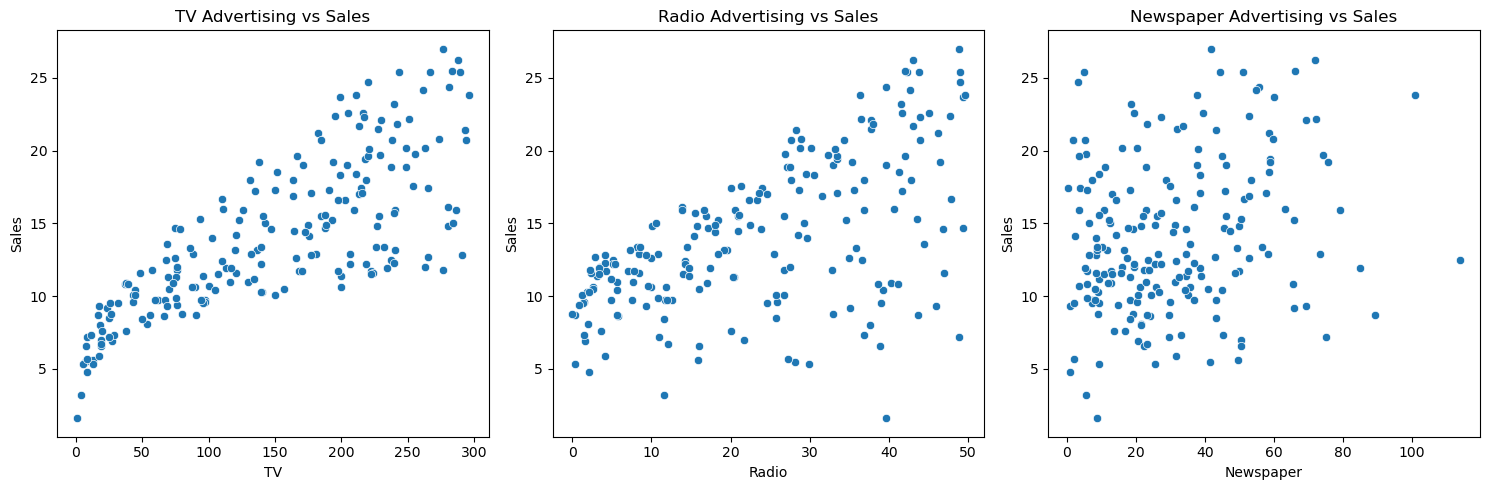

In [6]:
plt.figure(figsize=(15, 5))

# TV vs Sales
plt.subplot(1, 3, 1)
sns.scatterplot(data=df, x="TV", y="Sales")
plt.title("TV Advertising vs Sales")

# Radio vs Sales
plt.subplot(1, 3, 2)
sns.scatterplot(data=df, x="Radio", y="Sales")
plt.title("Radio Advertising vs Sales")

# Newspaper vs Sales
plt.subplot(1, 3, 3)
sns.scatterplot(data=df, x="Newspaper", y="Sales")
plt.title("Newspaper Advertising vs Sales")

plt.tight_layout()
plt.show()

Correlation Matrix:


,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.782224
Radio,0.054809,1.000000,0.354104,0.576223
Newspaper,0.056648,0.354104,1.000000,0.228299
Sales,0.782224,0.576223,0.228299,1.000000


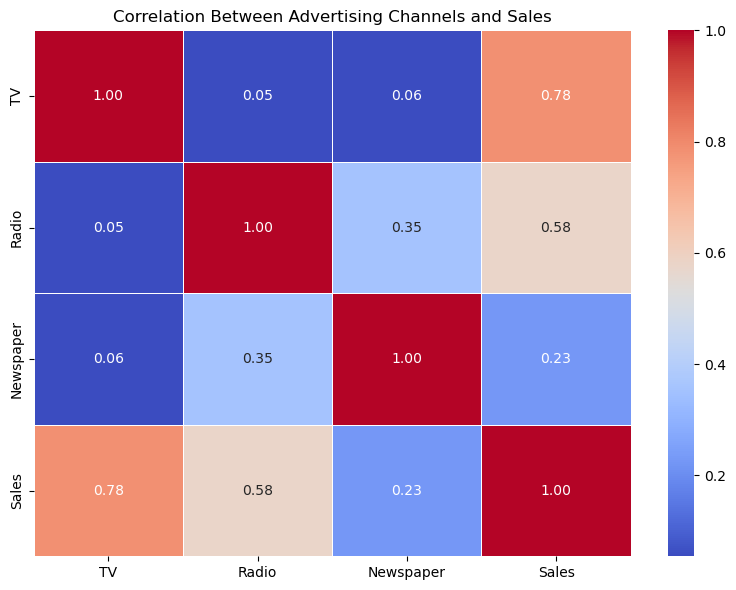

In [7]:
correlation = df[["TV", "Radio", "Newspaper", "Sales"]].corr()

print("Correlation Matrix:")
display(correlation)

plt.figure(figsize=(8, 6))
sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Between Advertising Channels and Sales")
plt.tight_layout()
plt.show()

## Exploratory Data Analysis

The exploratory analysis was performed to understand the relationship between
advertising expenditure and sales.

Scatter plots were created to visualize the relationship between TV, Radio,
Newspaper advertising and Sales.

A correlation heatmap was also used to measure the strength and direction of
relationships between the variables.

The analysis helps identify which advertising channels have stronger
relationships with sales and provides useful information for building the
sales prediction model.

In [8]:
# Select input features
X = df[["TV", "Radio", "Newspaper"]]

# Select target variable
y = df["Sales"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

print("\nFeatures Shape:", X.shape)
print("Target Shape:", y.shape)

Features (X):


,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4



Target (y):


0    22.1
1    10.4
2     9.3
3    18.5
4    12.9
Name: Sales, dtype: float64


Features Shape: (200, 3)
Target Shape: (200,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [10]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# Create models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    )
}

# Train each model
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"{name} trained successfully!")

Linear Regression trained successfully!
Decision Tree trained successfully!
Random Forest trained successfully!


In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

results = []

for name, model in models.items():
    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    mse = mean_squared_error(y_test, predictions)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R² Score": r2
    })

results_df = pd.DataFrame(results)

display(results_df)

,Model,MAE,MSE,RMSE,R² Score
0,Linear Regression,1.460757,3.174097,1.781600,0.899438
1,Decision Tree,0.985000,2.175000,1.474788,0.931091
2,Random Forest,0.620100,0.590732,0.768591,0.981284


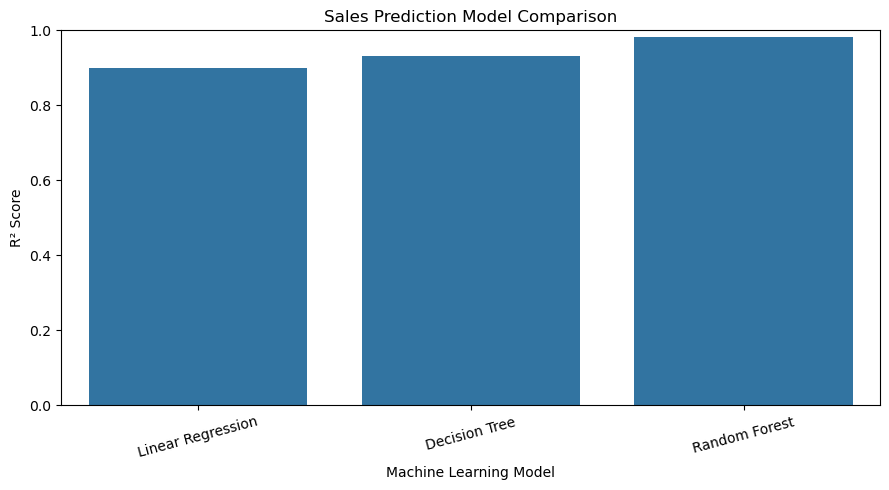

In [12]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results_df,
    x="Model",
    y="R² Score"
)

plt.title("Sales Prediction Model Comparison")
plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")
plt.ylim(0, 1)
plt.xticks(rotation=15)

plt.tight_layout()
plt.show()

In [13]:
best_model_name = results_df.loc[
    results_df["R² Score"].idxmax(),
    "Model"
]

best_model = models[best_model_name]

best_r2 = results_df.loc[
    results_df["R² Score"].idxmax(),
    "R² Score"
]

print("Best Model:", best_model_name)
print(f"Best R² Score: {best_r2:.4f}")

Best Model: Random Forest
Best R² Score: 0.9813


In [14]:
# Make predictions using the best model
best_predictions = best_model.predict(X_test)

# Compare actual and predicted values
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": best_predictions
})

display(comparison.head(10))

,Actual Sales,Predicted Sales
0,16.9,17.698
1,22.4,21.804
2,21.4,20.628
3,7.3,6.793
4,24.7,22.927
5,12.6,13.379
6,22.3,22.376
7,8.4,9.688
8,11.5,11.826
9,14.9,15.540


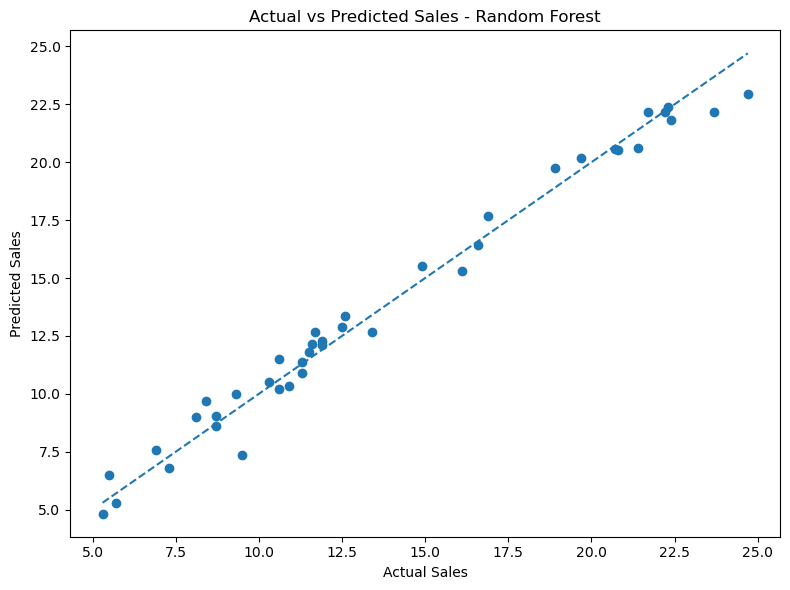

In [15]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, best_predictions)

# Perfect prediction reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title(f"Actual vs Predicted Sales - {best_model_name}")

plt.tight_layout()
plt.show()

In [16]:
# Example advertising budget
new_advertising = pd.DataFrame({
    "TV": [150],
    "Radio": [25],
    "Newspaper": [20]
})

predicted_sales = best_model.predict(new_advertising)

print("Advertising Budget:")
display(new_advertising)

print(f"Predicted Sales: {predicted_sales[0]:.2f}")

Advertising Budget:


,TV,Radio,Newspaper
0,150,25,20


Predicted Sales: 15.15


In [17]:
if best_model_name == "Linear Regression":
    coefficients = pd.DataFrame({
        "Feature": X.columns,
        "Coefficient": best_model.coef_
    })

    coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()

    display(coefficients.sort_values(
        by="Absolute Coefficient",
        ascending=False
    ))
else:
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    })

    display(feature_importance.sort_values(
        by="Importance",
        ascending=False
    ))

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


## Conclusion

This project developed a machine learning model to predict sales based on
advertising expenditure across different media channels.

The dataset was explored and analyzed using statistical summaries,
scatter plots, and a correlation heatmap.

Three regression models were implemented:

1. Linear Regression
2. Decision Tree Regressor
3. Random Forest Regressor

The models were evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² Score

The best-performing model was selected based on its R² Score.

The selected model was then used to predict sales for a new advertising
budget. Actual and predicted sales values were also compared to evaluate
the model's performance.

Overall, this project demonstrates how machine learning regression
techniques can be used to understand the relationship between advertising
expenditure and sales and to make sales predictions.